In [1]:
import pandas as pd
import numpy as np
import torch
from torch import nn
import torchvision
from torchvision import datasets
import matplotlib.pyplot as plt 
from torch.utils.data import DataLoader


In [2]:
transform = torchvision.transforms.ToTensor()

train_data = datasets.CIFAR10(
    root="data",
    train=True,
    download=False,
    transform=transform
)

test_data = datasets.CIFAR10(
    root="data",
    train=False,
    download=False,
    transform=transform
)

In [3]:
len(train_data),len(test_data)

(50000, 10000)

In [4]:
class_names=train_data.classes
class_names

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

In [5]:
train_data.class_to_idx

{'airplane': 0,
 'automobile': 1,
 'bird': 2,
 'cat': 3,
 'deer': 4,
 'dog': 5,
 'frog': 6,
 'horse': 7,
 'ship': 8,
 'truck': 9}

In [6]:
train_data[0][0].shape

torch.Size([3, 32, 32])

In [7]:
ops=train_data.targets
ops

[6,
 9,
 9,
 4,
 1,
 1,
 2,
 7,
 8,
 3,
 4,
 7,
 7,
 2,
 9,
 9,
 9,
 3,
 2,
 6,
 4,
 3,
 6,
 6,
 2,
 6,
 3,
 5,
 4,
 0,
 0,
 9,
 1,
 3,
 4,
 0,
 3,
 7,
 3,
 3,
 5,
 2,
 2,
 7,
 1,
 1,
 1,
 2,
 2,
 0,
 9,
 5,
 7,
 9,
 2,
 2,
 5,
 2,
 4,
 3,
 1,
 1,
 8,
 2,
 1,
 1,
 4,
 9,
 7,
 8,
 5,
 9,
 6,
 7,
 3,
 1,
 9,
 0,
 3,
 1,
 3,
 5,
 4,
 5,
 7,
 7,
 4,
 7,
 9,
 4,
 2,
 3,
 8,
 0,
 1,
 6,
 1,
 1,
 4,
 1,
 8,
 3,
 9,
 6,
 6,
 1,
 8,
 5,
 2,
 9,
 9,
 8,
 1,
 7,
 7,
 0,
 0,
 6,
 9,
 1,
 2,
 2,
 9,
 2,
 6,
 6,
 1,
 9,
 5,
 0,
 4,
 7,
 6,
 7,
 1,
 8,
 1,
 1,
 2,
 8,
 1,
 3,
 3,
 6,
 2,
 4,
 9,
 9,
 5,
 4,
 3,
 6,
 7,
 4,
 6,
 8,
 5,
 5,
 4,
 3,
 1,
 8,
 4,
 7,
 6,
 0,
 9,
 5,
 1,
 3,
 8,
 2,
 7,
 5,
 3,
 4,
 1,
 5,
 7,
 0,
 4,
 7,
 5,
 5,
 1,
 0,
 9,
 6,
 9,
 0,
 8,
 7,
 8,
 8,
 2,
 5,
 2,
 3,
 5,
 0,
 6,
 1,
 9,
 3,
 6,
 9,
 1,
 3,
 9,
 6,
 6,
 7,
 1,
 0,
 9,
 5,
 8,
 5,
 2,
 9,
 0,
 8,
 8,
 0,
 6,
 9,
 1,
 1,
 6,
 3,
 7,
 6,
 6,
 0,
 6,
 6,
 1,
 7,
 1,
 5,
 8,
 3,
 6,
 6,
 8,
 6,
 8,
 4,
 6,
 6,


In [8]:
image,label=train_data[1]

9

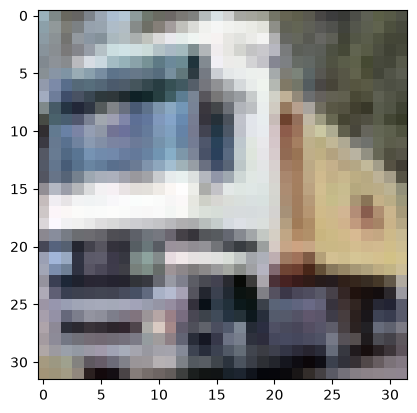

In [9]:
plt.imshow(image.permute(1, 2, 0)) 
label

In [10]:
image.shape

torch.Size([3, 32, 32])

In [11]:
train_dataloader = DataLoader(
    train_data,
    batch_size=32,
    shuffle=True
)

test_dataloader = DataLoader(
    test_data,
    batch_size=32,
    shuffle=False
)

In [12]:
image.shape

torch.Size([3, 32, 32])

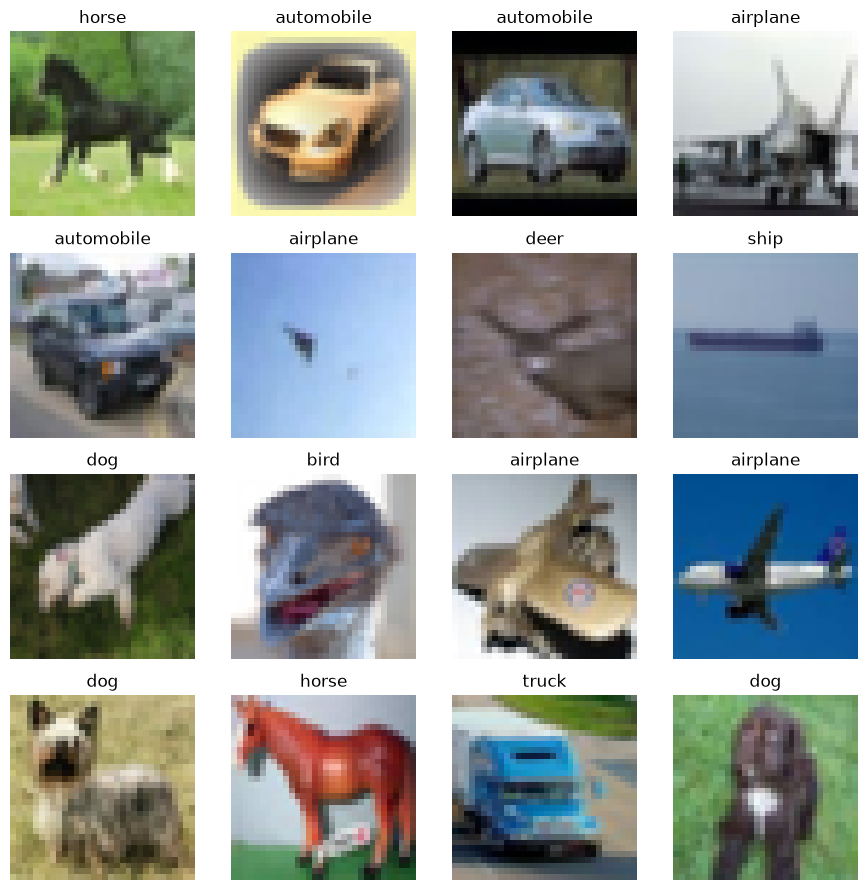

In [13]:
# torch.manual_seed(42)
fig = plt.figure(figsize=(9, 9))
rows, cols = 4, 4

for i in range(1, rows * cols + 1):
    random_idx = torch.randint(0, len(train_data), size=[1]).item()

    img, label = train_data[random_idx]
    fig.add_subplot(rows, cols, i)
    
    # FIX 1: Use permute instead of squeeze to handle (3, 32, 32) -> (32, 32, 3)
    plt.imshow(img.permute(1, 2, 0)) 
    
    plt.title(class_names[label])
    
    # FIX 2: Use the string "off" instead of False
    plt.axis("off") 

plt.tight_layout() # Bonus: Keeps titles and images from overlapping
plt.show()


In [14]:
class CnnModel1(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()

        self.conv_layer = nn.Sequential(
            # Conv 1
            nn.Conv2d(
                in_channels=input_shape,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(),

            # Conv 2
            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(),

            # Max Pool 1
            nn.MaxPool2d(kernel_size=2),

            # Conv 3
            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(),

            # Conv 4
            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(),

            # Max Pool 2
            nn.MaxPool2d(kernel_size=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(
                in_features=hidden_units * 8 * 8,
                out_features=128
            ),
            nn.ReLU(),
            nn.Linear(
                in_features=128,
                out_features=output_shape
            )
        )

    def forward(self, x):
        x = self.conv_layer(x)
        #print("After Conv:", x.shape)

        x = self.classifier(x)
        #print("After Classifier:", x.shape)

        return x

In [15]:
image.shape

torch.Size([3, 32, 32])

In [16]:
torch.manual_seed(42)
model=CnnModel1(input_shape=3,hidden_units=30,output_shape=len(class_names))

In [17]:
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [18]:
image,label=next(iter(train_dataloader))

predictions=model(image)
print(predictions.shape)
loss=loss_fn(predictions,label)
print(loss)

torch.Size([32, 10])
tensor(2.3025, grad_fn=<NllLossBackward0>)


In [ ]:
epochs = 10

for epoch in range(epochs):
    model.train()
    for image, label in train_dataloader:
        y_pred = model(image)

        loss = loss_fn(y_pred, label)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()


model.eval()

with torch.inference_mode():
    for image, label in test_dataloader:
        y_pred = model(image)
        

In [21]:
all_preds = []
all_labels = []

model.eval()

with torch.inference_mode():
    for image, label in test_dataloader:
        y_pred = model(image)
        loss = loss_fn(y_pred, label)

        predicted = torch.argmax(y_pred, dim=1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(label.cpu().numpy())

In [23]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(all_labels, all_preds)

print("Accuracy:", accuracy)

Accuracy: 0.7056


In [29]:
all_preds

[np.int64(3),
 np.int64(8),
 np.int64(8),
 np.int64(0),
 np.int64(6),
 np.int64(6),
 np.int64(1),
 np.int64(6),
 np.int64(3),
 np.int64(1),
 np.int64(0),
 np.int64(9),
 np.int64(5),
 np.int64(7),
 np.int64(9),
 np.int64(8),
 np.int64(5),
 np.int64(5),
 np.int64(8),
 np.int64(6),
 np.int64(7),
 np.int64(2),
 np.int64(4),
 np.int64(9),
 np.int64(4),
 np.int64(4),
 np.int64(4),
 np.int64(0),
 np.int64(9),
 np.int64(6),
 np.int64(6),
 np.int64(5),
 np.int64(4),
 np.int64(3),
 np.int64(9),
 np.int64(1),
 np.int64(4),
 np.int64(9),
 np.int64(9),
 np.int64(5),
 np.int64(4),
 np.int64(6),
 np.int64(5),
 np.int64(6),
 np.int64(0),
 np.int64(9),
 np.int64(4),
 np.int64(4),
 np.int64(7),
 np.int64(4),
 np.int64(9),
 np.int64(8),
 np.int64(6),
 np.int64(3),
 np.int64(8),
 np.int64(8),
 np.int64(7),
 np.int64(3),
 np.int64(5),
 np.int64(3),
 np.int64(7),
 np.int64(3),
 np.int64(6),
 np.int64(9),
 np.int64(6),
 np.int64(6),
 np.int64(1),
 np.int64(2),
 np.int64(5),
 np.int64(7),
 np.int64(8),
 np.in

In [28]:
all_labels

[np.int64(3),
 np.int64(8),
 np.int64(8),
 np.int64(0),
 np.int64(6),
 np.int64(6),
 np.int64(1),
 np.int64(6),
 np.int64(3),
 np.int64(1),
 np.int64(0),
 np.int64(9),
 np.int64(5),
 np.int64(7),
 np.int64(9),
 np.int64(8),
 np.int64(5),
 np.int64(7),
 np.int64(8),
 np.int64(6),
 np.int64(7),
 np.int64(0),
 np.int64(4),
 np.int64(9),
 np.int64(5),
 np.int64(2),
 np.int64(4),
 np.int64(0),
 np.int64(9),
 np.int64(6),
 np.int64(6),
 np.int64(5),
 np.int64(4),
 np.int64(5),
 np.int64(9),
 np.int64(2),
 np.int64(4),
 np.int64(1),
 np.int64(9),
 np.int64(5),
 np.int64(4),
 np.int64(6),
 np.int64(5),
 np.int64(6),
 np.int64(0),
 np.int64(9),
 np.int64(3),
 np.int64(9),
 np.int64(7),
 np.int64(6),
 np.int64(9),
 np.int64(8),
 np.int64(0),
 np.int64(3),
 np.int64(8),
 np.int64(8),
 np.int64(7),
 np.int64(7),
 np.int64(4),
 np.int64(6),
 np.int64(7),
 np.int64(3),
 np.int64(6),
 np.int64(3),
 np.int64(6),
 np.int64(2),
 np.int64(1),
 np.int64(2),
 np.int64(3),
 np.int64(7),
 np.int64(2),
 np.in